## Overview
The project looks at the GB power market, utilising hourly data for GB day-ahead prices, wind and solar generation. Granger causality and spectral analysis is used to find the relationships between renewables and price fluctuations. A battery simulation has also been constructed to see how the spread of charge and discharge prices can vary net revenue of the battery.

## Dataset
The dataset used can be found https://data.open-power-system-data.org/time_series/2020-10-06. The dataset chosen for this project uses hourly data (01-01-2015 - 30-09-2020) specifically for the GB market, specifically variables for day-ahead prices, wind and solar generation. While all variable data has been cleaned for this project, only price and generation variables have been used thus far. Other variables may be integrated into further analysis conducted on this dataset.

## Data Cleaning

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import grangercausalitytests
import seaborn as sns


### Data Cleaning

df = pd.read_csv("C:/Users/ieddy/OneDrive/Documents/Python Scripts/GB Power Modelling Dataset.csv")
df = df.sort_values("utc_timestamp").reset_index(drop=True)

# Adjust timestamps
df['utc_timestamp'] = pd.to_datetime(df['utc_timestamp'])

# All generation and capacity columns cleaned for completeness
# Offshore/onshore split retained for potential future analysis

# Forward fill capacities for wind and solar. Capacities do not regularly change, so assuming constant is justified
df["GB_GBN_solar_capacity"] = df["GB_GBN_solar_capacity"].ffill()
df["GB_GBN_wind_capacity"] = df["GB_GBN_wind_capacity"].ffill()
df["GB_GBN_wind_offshore_capacity"] = df["GB_GBN_wind_offshore_capacity"].ffill()
df["GB_GBN_wind_onshore_capacity"] = df["GB_GBN_wind_onshore_capacity"].ffill()

# Interpolate day ahead prices and generation due to constant changes hourly
df["GB_GBN_load_actual_entsoe_transparency"] = df["GB_GBN_load_actual_entsoe_transparency"].interpolate()
df["GB_GBN_load_forecast_entsoe_transparency"] = df["GB_GBN_load_forecast_entsoe_transparency"].interpolate()
df["GB_GBN_price_day_ahead"] = df["GB_GBN_price_day_ahead"].interpolate()
df["GB_GBN_solar_generation_actual"] = df["GB_GBN_solar_generation_actual"].interpolate()
df["GB_GBN_wind_generation_actual"] = df["GB_GBN_wind_generation_actual"].interpolate()
df["GB_GBN_wind_offshore_generation_actual"] = df["GB_GBN_wind_offshore_generation_actual"].interpolate()
df["GB_GBN_wind_onshore_generation_actual"] = df["GB_GBN_wind_onshore_generation_actual"].interpolate()

# Profiles are re-calculated using filled generation and capacity values to ensure consistency
df["GB_GBN_solar_profile"] = df["GB_GBN_solar_generation_actual"] / df["GB_GBN_solar_capacity"]
df["GB_GBN_wind_profile"] = df["GB_GBN_wind_generation_actual"] / df["GB_GBN_wind_capacity"]
df["GB_GBN_wind_offshore_profile"] = df["GB_GBN_wind_offshore_generation_actual"] / df["GB_GBN_wind_offshore_capacity"]
df["GB_GBN_wind_onshore_profile"] = df["GB_GBN_wind_onshore_generation_actual"] / df["GB_GBN_wind_onshore_capacity"]

df = df.dropna() # check to drop any remaining N/As


The above code demonstrates the importing of packages and the dataset. For capacity, forward fill was used to fill data gaps, due to capacity not changing regularly over the course of the dataset. Load, price, and generation values were interpolated due to volatility in the values, and the data could be assumed through averaging from the surrounding values. Profile was calculated using the newly filled actual and capacity values for consistency. All remaining missing values were then removed from the dataframe to ensure a clean, complete dataset for analysis.

## Exploratory Analysis

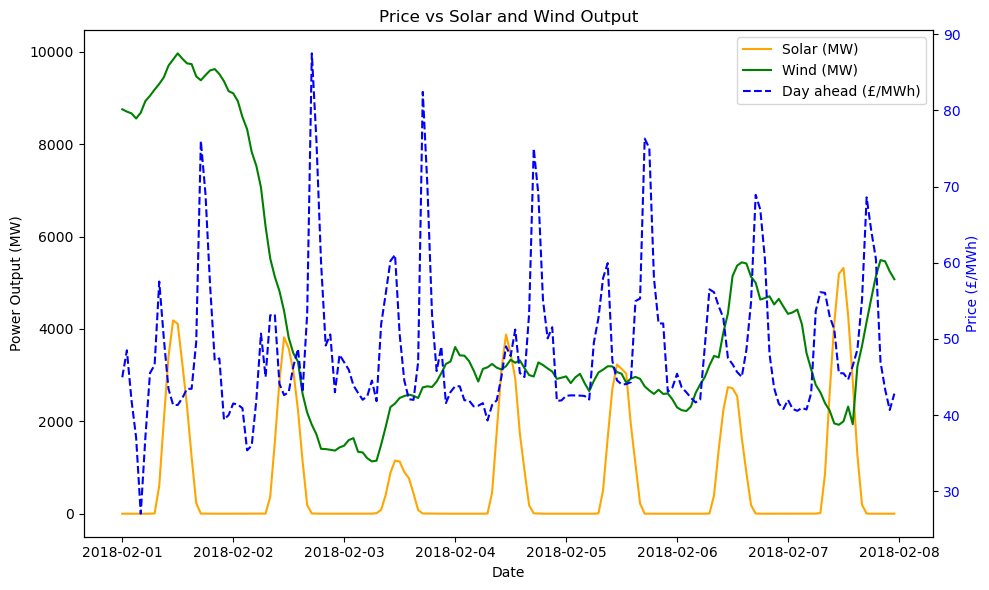

In [3]:
# Extract the set time frame from February for the following graph
df_week_feb = df[(df['utc_timestamp'] >= '2018-02-01') & 
             (df['utc_timestamp'] < '2018-02-08')]

# Below is a two-axis plot that shows wind and solar generation alongside price
fig, ax1 = plt.subplots(figsize=(10,6))

# Create first axis to show power generation for wind and solar
ln1 = ax1.plot(df_week_feb['utc_timestamp'], df_week_feb['GB_GBN_solar_generation_actual'], color='orange', label='Solar (MW)')
ln2 = ax1.plot(df_week_feb['utc_timestamp'], df_week_feb['GB_GBN_wind_generation_actual'], color='green', label='Wind (MW)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Power Output (MW)', color='black')
ax1.tick_params(axis='y')


# Create secondary axis for price
ax2 = ax1.twinx()
ln3 = ax2.plot(df_week_feb['utc_timestamp'], df_week_feb['GB_GBN_price_day_ahead'], color='blue', label='Day ahead (£/MWh)', linestyle='--')
ax2.set_ylabel('Price (£/MWh)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Combine legends
lns = ln1 + ln2 + ln3
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper right')

plt.title('Price vs Solar and Wind Output')
fig.tight_layout() # Ensures labels don't overlap
plt.show()

The above demonstrates the basic relationship between solar generation, wind generation and the day ahead price over a week. Price and solar show regular cycles, with price showing the ramps that are common daily, and solar the periods of high sunshine each day. The wind curve demonstrates a much more volatile trend, not seemingly correlated with solar or prices.

                            GB_GBN_price_day_ahead  total_renewable_generation
GB_GBN_price_day_ahead                    1.000000                   -0.103408
total_renewable_generation               -0.103408                    1.000000


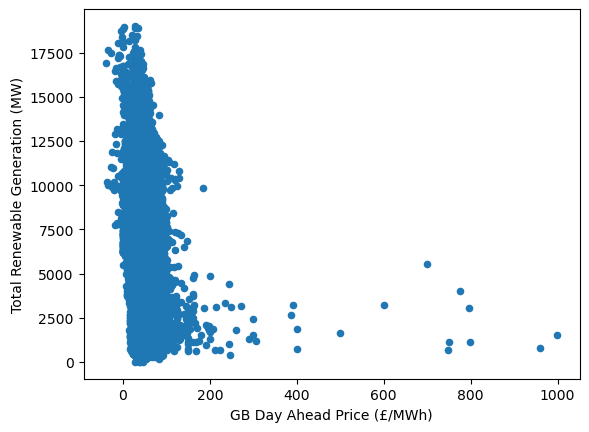

In [12]:
# Correlation analysis and scatter plot for price against total renewable generation - shows merit order
df["total_renewable_generation"] = df["GB_GBN_solar_generation_actual"] + df["GB_GBN_wind_generation_actual"]

print(df[["GB_GBN_price_day_ahead", "total_renewable_generation"]].corr())

df.plot.scatter("GB_GBN_price_day_ahead", "total_renewable_generation")
plt.xlabel("GB Day Ahead Price (£/MWh)")
plt.ylabel("Total Renewable Generation (MW)")
plt.show()

The above plot shows the correlation between day ahead prices and total renewable generation (calculated through the sum of wind and solar generation). While the overall correlation is low (-0.103), the scatter plot clearly demonstrates the relationship between renewable generation and lower day ahead prices. This links to the merit order within the GB power market, and how increased renewable power generation are associated with lower prices due to lower costs.

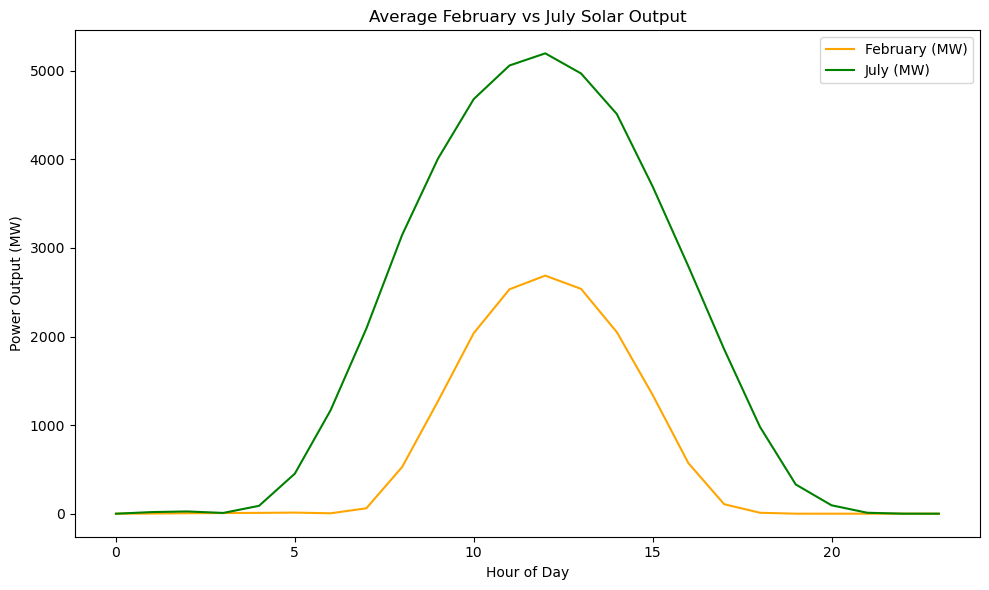

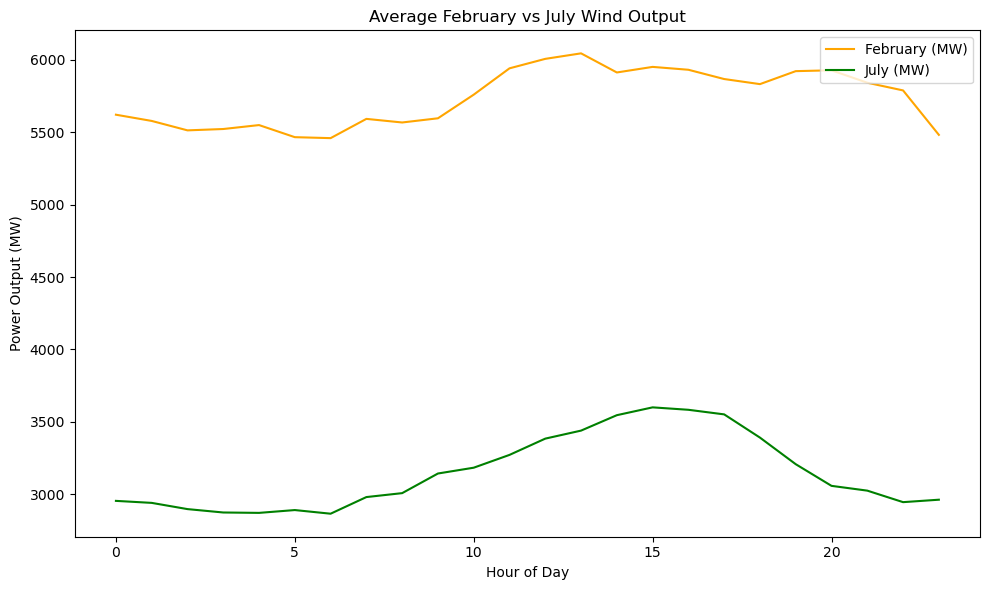

In [13]:
# Changes timestamps to hourly, and extract hourly means across the years for February and July
df["hour"] = df["utc_timestamp"].dt.hour

df_feb = df[df["utc_timestamp"].dt.month == 2]
feb_hourly = df_feb.groupby("hour")[["GB_GBN_solar_generation_actual", "GB_GBN_wind_generation_actual"]].mean()

df_jul = df[df["utc_timestamp"].dt.month == 7]
jul_hourly = df_jul.groupby("hour")[["GB_GBN_solar_generation_actual", "GB_GBN_wind_generation_actual"]].mean()

# Generate plots to show February and July comparison for solar and wind generation over average 24 hours
def plot_hourly_comparison(feb_hourly, jul_hourly, column, title):
    fig, ax1 = plt.subplots(figsize=(10,6))

    ln1 = ax1.plot(feb_hourly.index, feb_hourly[column], color='orange', label='February (MW)')
    ln2 = ax1.plot(jul_hourly.index, jul_hourly[column], color='green', label='July (MW)')
    ax1.set_xlabel('Hour of Day')
    ax1.set_ylabel('Power Output (MW)', color='black')
    ax1.tick_params(axis='y')

    # Combine legends
    lns = ln1 + ln2
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, loc='upper right')

    plt.title(title)
    fig.tight_layout() # Ensures labels don't overlap
    plt.show()
    
plot_hourly_comparison(feb_hourly, jul_hourly, "GB_GBN_solar_generation_actual", "Average February vs July Solar Output")
plot_hourly_comparison(feb_hourly, jul_hourly, "GB_GBN_wind_generation_actual", "Average February vs July Wind Output")


The plots above show the difference in wind and solar generation average over the day between February and July. 

The solar generation plot clearly shows a bell curve for both curves, with July signalling much higher generation than February. The bell curve shows the known assumption that sunlight generally peaks in the middle of the day, and is at its lowest overnight. The difference between February and July shows the difference in the hours of sunlight across the year, with the summer months having more hours of sunlight than winter.

Wind generation demonstrates a more subtle trend, with a slight peak found during mid-afternoon. Wind generation is also significantly higher in February than July, which demonstrates the difference between winter and summer weather.

## Statistical Analysis



In [6]:
result_price = adfuller(df["GB_GBN_price_day_ahead"])
print(f"Price ADF statistic: {result_price[0]:.4f}, p-value: {result_price[1]:.4e}")

result_renewables = adfuller(df["total_renewable_generation"])
print(f"Renewables ADF statistic: {result_renewables[0]:.4f}, p-value: {result_renewables[1]:.4e}")

result_renewables_solar = adfuller(df["GB_GBN_solar_generation_actual"])
print(f"Solar Generation ADF statistic: {result_renewables_solar[0]:.4f}, p-value: {result_renewables_solar[1]:.4e}")

result_renewables_wind = adfuller(df["GB_GBN_wind_generation_actual"])
print(f"Wind Generation ADF statistic: {result_renewables_wind[0]:.4f}, p-value: {result_renewables_wind[1]:.4e}")

Price ADF statistic: -10.5607, p-value: 7.7401e-19
Renewables ADF statistic: -18.4454, p-value: 2.1579e-30
Solar Generation ADF statistic: -10.7287, p-value: 3.0181e-19
Wind Generation ADF statistic: -16.1210, p-value: 4.8984e-29


Prior to main statistical analysis tests, ADF test statistics were strongly negative with p-values approaching zero for all series, confirming stationarity.

In [7]:
# Granger Causality Tests - renewable generation vs day ahead price
results_gc_total = grangercausalitytests(df[["GB_GBN_price_day_ahead", "total_renewable_generation"]], 24, verbose=False)
results_gc_solar = grangercausalitytests(df[["GB_GBN_price_day_ahead", "GB_GBN_solar_generation_actual"]], 24, verbose=False)
results_gc_wind = grangercausalitytests(df[["GB_GBN_price_day_ahead", "GB_GBN_wind_generation_actual"]], 24, verbose=False)

# Extract minimum p-values across all lags for each test
min_p_total = min(result[0]["ssr_ftest"][1] for result in results_gc_total.values())
min_p_solar = min(result[0]["ssr_ftest"][1] for result in results_gc_solar.values())
min_p_wind = min(result[0]["ssr_ftest"][1] for result in results_gc_wind.values())

print("Granger Causality Summary:")
print(f"Total renewables → price: min p-value = {min_p_total:.2e} (significant at all 24 lags)")
print(f"Wind → price: min p-value = {min_p_wind:.2e} (significant at all 24 lags)")
print(f"Solar → price: min p-value = {min_p_solar:.2e} (significant at lags 2-24, lag 1 not significant)")

Granger Causality Summary:
Total renewables → price: min p-value = 0.00e+00 (significant at all 24 lags)
Wind → price: min p-value = 1.03e-196 (significant at all 24 lags)
Solar → price: min p-value = 0.00e+00 (significant at lags 2-24, lag 1 not significant)


Granger causality tests showed that both total renewables and wind both had causal effects on day-ahead prices across all hours of a 24 hour period. The reason for this is likely due to wind generation being highly volatile and harder to predict than solar generation, meaning any changes can lead to price changes at a faster pace. This is likely why solar generation is causal from hour 2 onwards, as it is easier to predict overall.

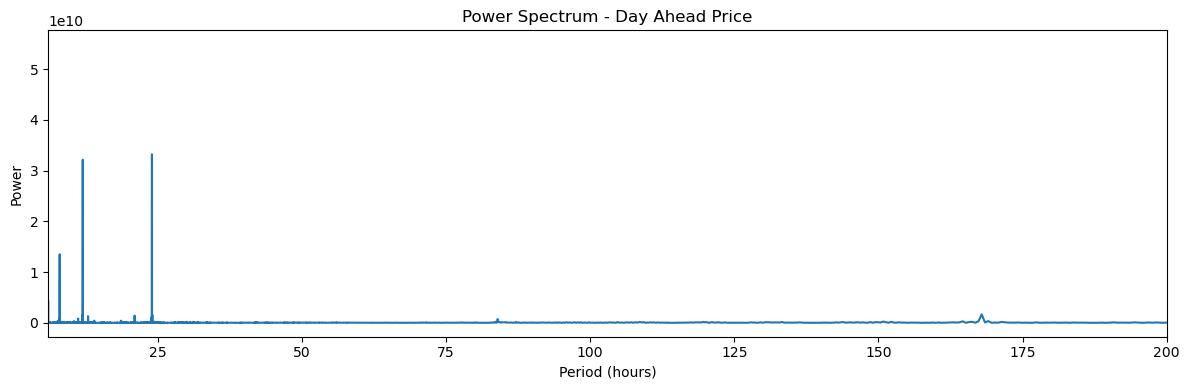

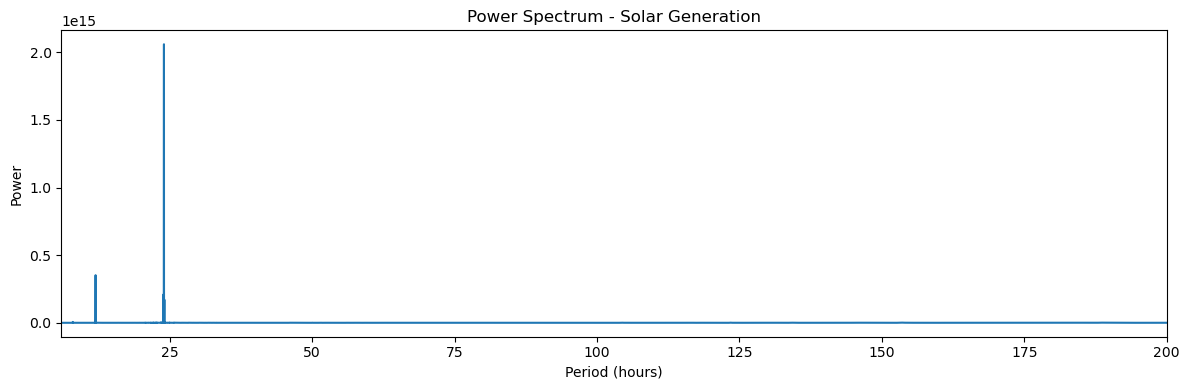

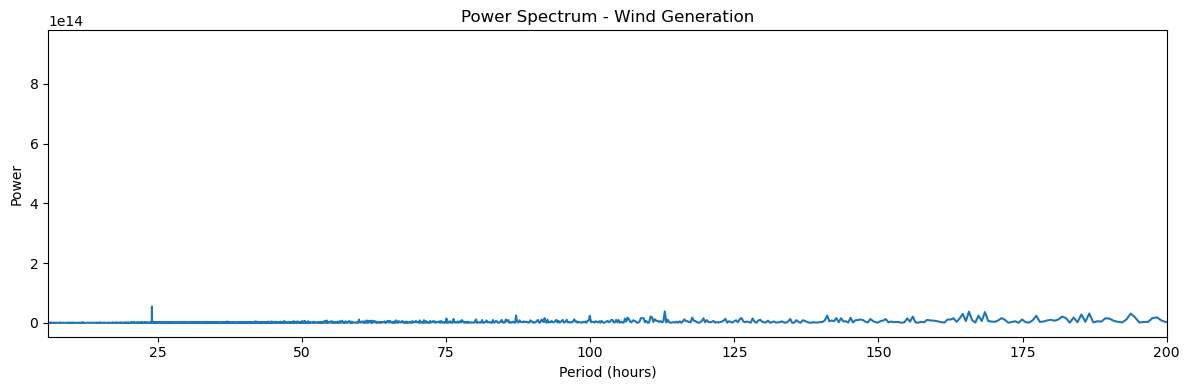

In [8]:
def plot_fft(series, title):
    fft_values = np.fft.fft(series)
    power = np.abs(fft_values) ** 2
    frequencies = np.fft.fftfreq(len(series), d=1)
    periods = 1 / frequencies
    mask = frequencies > 0
    plt.figure(figsize=(12, 4))
    plt.plot(periods[mask], power[mask])
    plt.xlim(6, 200)
    plt.xlabel("Period (hours)")
    plt.ylabel("Power")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_fft(df["GB_GBN_price_day_ahead"], "Power Spectrum - Day Ahead Price")
plot_fft(df["GB_GBN_solar_generation_actual"], "Power Spectrum - Solar Generation")
plot_fft(df["GB_GBN_wind_generation_actual"], "Power Spectrum - Wind Generation")


The above plots demonstrate a spectral analysis of day-ahead price, solar generation and wind generation. Key takeaways from these plots are that day-ahead prices and solar generation have dominant trends, with prices demonstrating a trend near the 12 and 24 hour marks. Solar generation follows a similar pattern, with trends found at 12 and 24 hours, which is in line with sunlight patterns. Wind generation does not follow the same pattern, with a slight trend found at the 24 hour mark. There is a lot of noise from the 100 hour mark onwards.

## Battery Simulation

In [9]:
# Battery: 200 MWh capacity, 50 MW rate limit, 85% efficiency, 100 MWh starting charge
# Base case dispatch: charge below £30/MWh, discharge above £55/MWh
# Sensitivity analysis tests charge thresholds £10-£40 and discharge thresholds £50-£90

df = df.reset_index(drop=True)

def calculate_battery_charge(GB_GBN_price_day_ahead, capacity, rate_limit,
                             efficiency, starting_charge, charge_threshold, discharge_threshold):
    current_charge = starting_charge
    results = []
    discharge_results = []
    revenue_results = []
    for i in range(len(df)):
        if GB_GBN_price_day_ahead[i] < 0:
            discharge = 0
            cost = 0
        elif GB_GBN_price_day_ahead[i] < charge_threshold and current_charge < capacity:
            previous_charge = current_charge
            current_charge = min(current_charge + rate_limit * efficiency, capacity)
            charge_amount = current_charge - previous_charge
            cost = charge_amount * GB_GBN_price_day_ahead[i]
            discharge = 0
        elif GB_GBN_price_day_ahead[i] > discharge_threshold and current_charge > 0:
            previous_charge = current_charge
            current_charge = max(current_charge - rate_limit * efficiency, 0)
            discharge = previous_charge - current_charge
            cost = 0
        else:
            discharge = 0
            cost = 0
        revenue = discharge * GB_GBN_price_day_ahead[i]
        net = revenue - cost
        results.append(current_charge)
        discharge_results.append(discharge)
        revenue_results.append(net)
    return results, discharge_results, revenue_results

Above shows the battery simulation, followed by the base case scenario. The battery operates through using day-ahead price signals, charging when below a set price and discharging when above another set price. This method echoes that of mainstream industrial batteries used on major power grids. Negative prices mean no charging or discharging takes place.

Parameters:

Capacity: 200 MWh
Rate limit: 50 MW per hour
Efficiency: 85%
Base case thresholds: charge below £30/MWh, discharge above £55/MWh

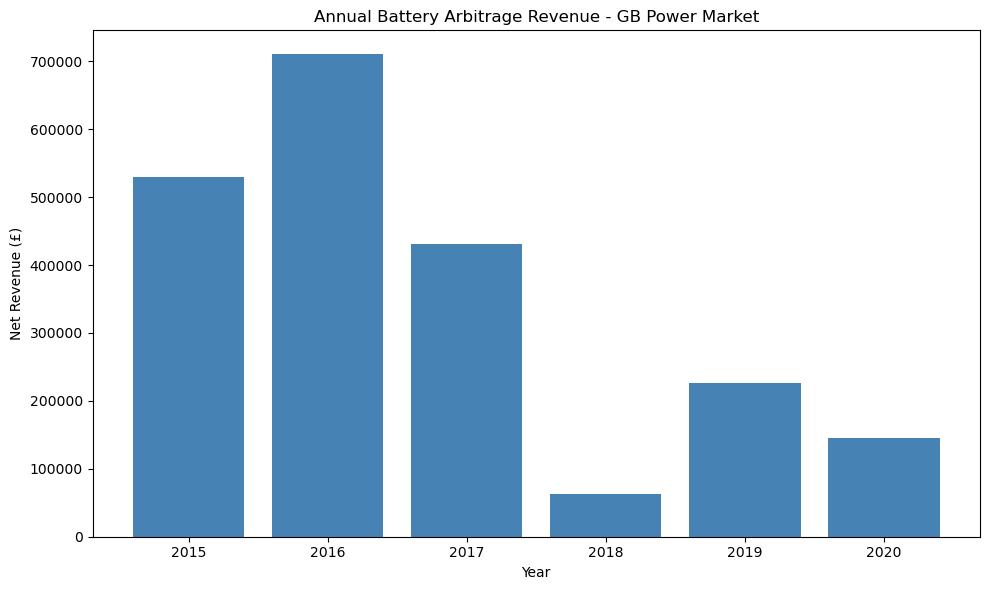

In [10]:
# Run base case simulation and store results
df["current_charge"], df["discharge"], df["net_revenue"] = calculate_battery_charge(
    df["GB_GBN_price_day_ahead"], 200, 50, 0.85, 100, 30, 55)

# Annual revenue breakdown
df["year"] = df["utc_timestamp"].dt.year

annual_revenue = df.groupby("year")["net_revenue"].sum()

plt.figure(figsize=(10, 6))
plt.bar(annual_revenue.index, annual_revenue.values, color='steelblue')
plt.xlabel("Year")
plt.ylabel("Net Revenue (£)")
plt.title("Annual Battery Arbitrage Revenue - GB Power Market")
plt.tight_layout()
plt.show()

The plot above shows the net revenues per year for the battery. It is clear that net revenue peaked in 2016, and decreased significantly since. The lowest year was 2018.

The following demonstrates a sensitivity analysis used to test the best charge and discharge levels for optimising net revenue:

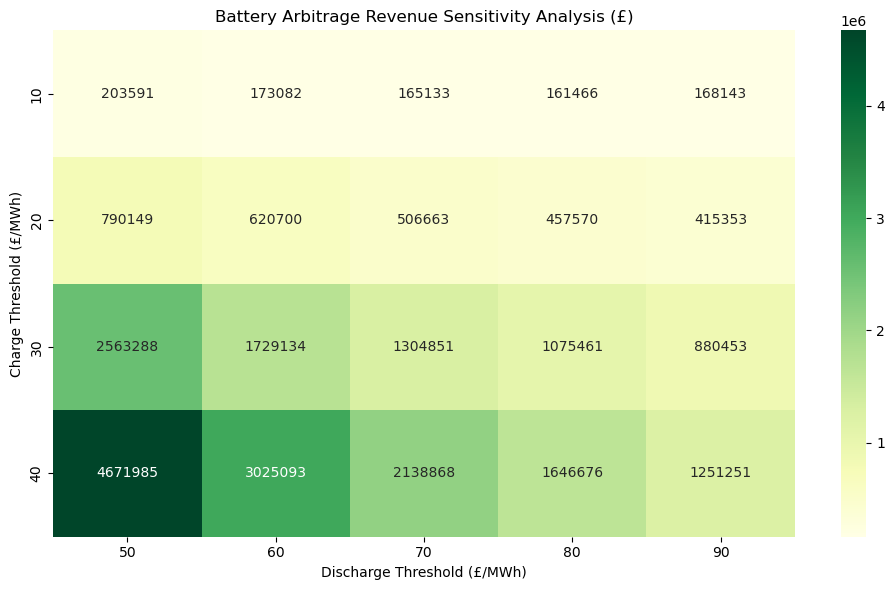

In [11]:
# Run sensitivity analysis across charge and discharge threshold combinations
sensitivity_results = {}
for charge_threshold in [10, 20, 30, 40]:
    for discharge_threshold in [50, 60, 70, 80, 90]:
        _, _, revenue = calculate_battery_charge(
            df["GB_GBN_price_day_ahead"], 200, 50, 0.85, 100,
            charge_threshold, discharge_threshold)
        sensitivity_results[(charge_threshold, discharge_threshold)] = sum(revenue)

# Sensitivity analysis heatmap
sensitivity_df = pd.DataFrame([
    {"charge": k[0], "discharge": k[1], "net_revenue": v}
    for k, v in sensitivity_results.items()
])

pivot = sensitivity_df.pivot(index="charge", columns="discharge", values="net_revenue")

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGn")
plt.title("Battery Arbitrage Revenue Sensitivity Analysis (£)")
plt.xlabel("Discharge Threshold (£/MWh)")
plt.ylabel("Charge Threshold (£/MWh)")
plt.tight_layout()
plt.show()

The heatmap above shows the combination of charge and discharge levels, and their corresponding net revenues. It is clear that the £40 charge and £50 discharge combination proved to be the most profitable. It should be noted though that in reality, with additional grid costs etc, this would likely prove not to be the most profitable overall.